In [1]:
import os,sys

# Set the path to the parent directory manually
parent_dir = os.path.abspath("../..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import pkg_resources
from datetime import datetime as dt, timedelta
from datetime import datetime
import glob
from netCDF4 import Dataset
from util.wrf_process import (calc_derive, object_tracking, read_and_write, to_polar)
from util.ml_framework import (cnn, vae)
from wrf import (to_np, getvar, smooth2d, get_cartopy, cartopy_xlim,
                 cartopy_ylim, latlon_coords, interplevel, ll_to_xy)
import gc,pickle
from tqdm import tqdm
import xarray as xr
from natsort import natsorted
from util.ml_preprocess import data_preproc
#from vae3d import VAEEncoder, VAEDecoder, VAE, elbo_loss, weights_init
import optuna
import random,math
import proplot as plot

/glade/derecho/scratch/ihtam/tmp/ipykernel_6611/1496010805.py:12: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [54]:
# --- 1. ProPlot Configuration for Aesthetic ---
# Resetting to ProPlot defaults is good practice, then apply specific styles.
plot.rc.reset() 

# Set global font size, family, and math font
plot.rc.update({
    'font.size': 11.5,          # Matched target aesthetic
    'font.name': 'DejaVu Sans', # A common, clean sans-serif like the target image
    'mathtext.fontset': 'dejavusans', # Match math font to text font
    'grid.alpha': 0.7,        # Make grid lines slightly transparent
    'grid.linewidth': 1.0,    # Thicker grid lines
    'grid.linestyle': '--',   # Dotted/dashed grid
    'grid.color': 'lightgray', # Light grey grid color
    'linewidth': 1.5,         # Default line width for spines and major ticks
    'ticklen': 5,             # Tick length
    'tickdir': 'out',         # Ticks point outward (or 'in' if preferred)
    'axes.spines.right': False, # Remove right spine
    'axes.spines.top': False,   # Remove top spine
    'axes.titlepad': 5.0,     # Adjust title padding if needed
    'legend.framealpha': 1.0,   # Opaque legend background
    'legend.facecolor': 'white',# White legend background
    'legend.edgecolor': '0.8',  # Light gray legend border
    'legend.fontsize': 9,      # Legend font size
    'legend.fancybox': True,    # Rounded corners for legend
# --- White Background Settings ---
    'figure.facecolor': 'white', # Set the color of the canvas/figure outside the axes
    'axes.facecolor': 'white',   # Set the color of the plotting area/axes background
})

/glade/derecho/scratch/ihtam/tmp/ipykernel_6611/1532609950.py:6: ProplotWarning: rc setting 'linewidth' was renamed to 'meta.width' in version 0.8.
  plot.rc.update({


In [2]:
class calc_diag:
    def __init__(self,WRFFILELIST,trackdata,startindx,preslv,zlv,weshape,nsshape):
        self.WRFFILELIST = WRFFILELIST
        self.trackdata = trackdata
        self.startindx = startindx
        self.preslv = preslv
        self.zlv = zlv
        self.weshape = weshape
        self.nsshape = nsshape

    def interp_to_preslv(self,vartointerp,prestointerp):
        nc_wp = [interplevel(vartointerp,prestointerp,i) for i in self.preslv]
        return np.asarray(nc_wp)

    def interp_to_zlv(self,vartointerp,prestointerp):
        nc_wp = [interplevel(vartointerp,prestointerp,i) for i in self.zlv]
        return np.asarray(nc_wp)
        
    def read_vars(self,varname):
        varout = []
        for i in range(len(self.WRFFILELIST)):
            varout.append(getvar(Dataset(self.WRFFILELIST[i]),varname))
        return np.asarray(varout)

    def read_vars_and_interp(self,varname,TYPE):
        varout = []
        for i in range(len(self.WRFFILELIST)):
            vartointerp = getvar(Dataset(self.WRFFILELIST[i]),varname)
            if TYPE=='pres':
                prestointerp = getvar(Dataset(self.WRFFILELIST[i]),'pres')
                varout.append(self.interp_to_preslv(vartointerp,prestointerp))
            elif TYPE=='height_agl':
                ztointerp = getvar(Dataset(self.WRFFILELIST[i]),'height_agl')
                varout.append(self.interp_to_zlv(vartointerp,ztointerp))
        return np.asarray(varout)

    def read_single_lv_vars(self,varname,TYPE):
        varout = []
        for i in range(len(self.WRFFILELIST)):
            varout.append(getvar(Dataset(self.WRFFILELIST[i]),varname))
        return np.asarray(varout)
        
    def find_track_ij(self):
        ixs,iys = [],[]
        for i, WRFFILE in tqdm(enumerate(self.WRFFILELIST)):
            # read file
            nc_ctrl = Dataset(WRFFILE)
            # Target location
            target_lat = self.trackdata['clat'][self.startindx+i] # Simulations start from 12 UTC
            target_lon = self.trackdata['clon'][self.startindx+i] # Simulations start from 12 UTC
            # Compute track indices
            ix, iy = ll_to_xy(nc_ctrl, target_lat, target_lon, timeidx=0) #x, y
            ixs.append(int(ix.values))
            iys.append(int(iy.values))
        return ixs,iys
        
    def compute_tc_shear(self, u, v, x0, y0, dx_km=3.0,
                     inner_km=200.0, outer_km=800.0,
                     p_top=200.0, p_bot=850.0):
        """
        Compute mean 200–850 hPa shear vector in a TC-centered annulus.

        Parameters
        ----------
        ds : netCDF Dataset (opened with netCDF4 or xarray + wrf-python)
            WRF output file handle
        x0, y0 : int
            TC center grid indices (x,y) in WRF domain
        dx_km : float
            Grid spacing (km)
        inner_km, outer_km : float
            Inner and outer radius of annulus (km)
        p_top, p_bot : float
            Top and bottom pressure levels (hPa)

        Returns
        -------
        shear_u, shear_v : floats
            Zonal and meridional shear components (m/s)
        shear_mag : float
            Shear magnitude (m/s)
        """

        # --- Interpolate to levels
        u200 = u[self.preslv.index(p_top),...]
        v200 = v[self.preslv.index(p_top),...]
        u850 = u[self.preslv.index(p_bot),...]
        v850 = v[self.preslv.index(p_bot),...]

        # --- Make distance mask in km
        ny, nx = u200.shape
        X, Y = np.meshgrid(np.arange(nx), np.arange(ny))
        dx = (X - x0) * dx_km
        dy = (Y - y0) * dx_km
        r = np.sqrt(dx**2 + dy**2)

        mask = (r >= inner_km) & (r <= outer_km)

        # --- Area-average wind in annulus
        u200m = np.nanmean(np.where(mask, u200, np.nan))
        v200m = np.nanmean(np.where(mask, v200, np.nan))
        u850m = np.nanmean(np.where(mask, u850, np.nan))
        v850m = np.nanmean(np.where(mask, v850, np.nan))

        # --- Shear vector
        shear_u = u200m - u850m
        shear_v = v200m - v850m
        shear_mag = np.sqrt(shear_u**2 + shear_v**2)

        return shear_u, shear_v, shear_mag

    def get_shear_mag_dir(self,Upres,Vpres,Xs,ys,settings=[200.0,800.0,200.0,850.0,3.0]):
        """
        settings = [inner_km,outer_km,p_top,p_bot,dx_km]
        """
        shear_mags,shear_dirs = [],[]
        shear_us, shear_vs = [],[]
        for i in range(len(Xs)):
            radiusshape = int(settings[1]/settings[4])
            if ((self.weshape-Xs[i])>radiusshape) and ((self.nsshape-ys[i])>radiusshape):
                shear_mags.append(np.nan)
                shear_dirs.append(np.nan)
                shear_us.append(np.nan)
                shear_vs.append(np.nan)
            else:
                shear_u, shear_v, shear_mag = self.compute_tc_shear(Upres[i,...], Vpres[i,...], Xs[i], ys[i], 
                                                                       dx_km=settings[4],
                                                                       inner_km=settings[0], outer_km=settings[1],
                                                                       p_top=settings[2], p_bot=settings[3])
                shear_mags.append(shear_mag)
                shear_dirs.append((np.degrees(np.arctan2(shear_v, shear_u)) % 360.0))
                shear_us.append(shear_u)
                shear_vs.append(shear_v)
        return shear_mags,shear_dirs, shear_vs, shear_us

    def data_to_TCcentre(self,data,Xs,ys,settings=[800.0,3.0,200.0]):
        dataTC = []
        for i in range(len(Xs)):
            radiusshape = int(settings[0]/settings[1])
            if ((self.weshape-Xs[i])>radiusshape) and ((self.nsshape-ys[i])>radiusshape):
                dataTC.append(np.nan)
            else:
                domainint = int(settings[2])
                if len(data.shape)==4:
                    dataTC.append(data[i,:,ys[i]-domainint:ys[i]+domainint,Xs[i]-domainint:Xs[i]+domainint])
                elif len(data.shape)==3:
                    dataTC.append(data[i,ys[i]-domainint:ys[i]+domainint,Xs[i]-domainint:Xs[i]+domainint])
        return np.asarray(dataTC)
            
    def data_to_polar(self,Cnc_wpz,dx,rmax,dr,nazim):        
        # Convert to polar coordinates
        # Suppose Xtrain_n shape = (n_samples, 9, ny, nx)
        ny, nx = Cnc_wpz.shape[-2:]
        if len(Cnc_wpz.shape)>3:
            tri, pts, target_points, r, az = to_polar.precompute_cartesian_to_polar_map(
                nx=nx, ny=ny, dx=dx, rmax=rmax, dr=dr, nazim=nazim
            )
            return to_polar.fast_cartesian_to_polar_batch(Cnc_wpz, tri, pts, target_points, r, az), r, az
        elif len(Cnc_wpz.shape)==3:
            Cnc_wpza = np.expand_dims(Cnc_wpz, axis=1)
            tri, pts, target_points, r, az = to_polar.precompute_cartesian_to_polar_map(
                nx=nx, ny=ny, dx=dx, rmax=rmax, dr=dr, nazim=nazim
            )
            return to_polar.fast_cartesian_to_polar_batch(Cnc_wpza, tri, pts, target_points, r, az), r, az

In [3]:
def get_proc_data_polar(track,ctrl_files,wantvar='rh',TYPE='height_agl'):    
    etalevels,weshape,nsshape = getvar(Dataset(ctrl_files[0]),'pres').shape
    wrfdiags = calc_diag(ctrl_files,track_memb03,12,[10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000],
                         [500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000,7500,8000,8500,9000,9500,10000],
                         weshape,nsshape)
    tracks_ij = wrfdiags.find_track_ij()

    # Shear calculation
    Upres,Vpres = wrfdiags.read_vars_and_interp('ua','pres'), wrfdiags.read_vars_and_interp('va','pres')

    shear_mags,shear_dirs,shear_uv,shear_vs = wrfdiags.get_shear_mag_dir(Upres,Vpres,tracks_ij[0],
                                                                         tracks_ij[1],
                                                                         settings=[200.0,800.0,int(200.0*100),int(850.0*100),3.0])
    # Calculate polar version of one variable
    if TYPE=='single':
        RHpres = wrfdiags.read_single_lv_vars(wantvar,TYPE)
    else:
        RHpres = wrfdiags.read_vars_and_interp(wantvar,TYPE)
    RHpres_ctre = wrfdiags.data_to_TCcentre(RHpres,tracks_ij[0],tracks_ij[1])
    RHpres_plr, r, az = wrfdiags.data_to_polar(RHpres_ctre,3,600,3,360)
    return {'trackkij':tracks_ij,'shearmags':shear_mags,'sheardirs':shear_dirs,'varcart':RHpres_ctre,'varpol':RHpres_plr, 'r':r, 'az':az}

In [4]:
# Track path
track_memb03 = xr.open_dataset('/glade/work/ihtam/storage/track_avor_850-600.nc')

ctrl_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan_perturb/ctrl/wrfout_d02_2013-11-0*"))[:24] #sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/ctrl/wrfout_d02_2013-11-0*"))[:6]
miaxi2x_files = sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/minus_2idealaxi/wrfout_d02_2013-11-0*"))[:24]
aiaxi2x_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan_perturb/add_2IDEAL/wrfout_d02_2013-11-0*"))[:24] #sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/add_2idealaxi/wrfout_d02_2013-11-0*"))[:6]
mdd_p2f_files =sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/minus_2DDp_pareto2/wrfout_d02_2013-11-0*"))[:24]
dd_p2f_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan_perturb/add_2ML_pp2/wrfout_d02_2013-11-0*"))[:24]

In [40]:
class msevar_budget:
    def __init__(self, pres, z, track, exps, expname):
        self.pres = pres # Pressure levels
        self.z = z # AGL Height levels
        self.track = track # TC track
        self.exps = exps # List storing experiment filenames (list)
        self.expname = expname # Name of experiments

    def proc_onevar(self,wantvar,TYPE):
        """
        wantvar: Variable name to extract and convert (wrf-python)
        TYPE: Integrate to height AGL (height_agl) or pressure (pres)
        """
        vardict = {}
        for expname,expfilelist in zip(self.expname,self.exps):
            vardict[expname] = get_proc_data_polar(self.track,expfilelist,wantvar=wantvar,TYPE=TYPE)
        return vardict

    def rotating_polar_onevar(self,vardict,sheardict):
        rotated_vardict = {}
        for expnamez in self.expname:
            if type(vardict[expnamez])==np.ndarray:
                temp = vardict[expnamez]
            else:
                temp = vardict[expnamez]['varpol']
            sheardir = sheardict[expnamez]['sheardirs']
            rotatemp = np.asarray([np.roll(temp[i],shift=-int(sheardir[i]), axis=-1) for i in range(len(temp))])
            rotated_vardict[expnamez] = rotatemp
        return rotated_vardict

    def calc_den(self,tkdict,qvdict,presdict):
        dendict = {}
        for expnamez in self.expname:
            dendict[expnamez] = proc_vars.density_moist(tkdict[expnamez]['varpol'],qvdict[expnamez]['varpol'],presdict[expnamez]['varpol'])
        return dendict

    def calc_imse(self,qvdict,tkdict,presdict,gzdict,dp=10000):
        cp=1004.  # J/K/kg
        cpl=4186. # J/k/kg
        cpv=1885. # J/K/kg
        lv0=2.5e6 # J/kg\
        g = 9.81 # m/s2
        p_int_top = 100e2 # top pressure-level to integrate to [Pa]
        
        imsedict = {}
        for expnamez in self.expname:
            qvapor = qvdict[expnamez]['varpol'] # kg/kg
            tmpk = tkdict[expnamez]['varpol'] # K
            pwrf = presdict[expnamez]['varpol'] # Pa
            gz = gzdict[expnamez]['varpol'] # m2/s2 = J/kg

            # Latent heat of vaporization
            lv = lv0 - (cpl-cpv)*(tmpk-273.15)
            # Moist static energy (MSE)
            mse = cp*tmpk + gz + lv*qvapor # J/kg
            imsedict[expnamez] = np.where(pwrf >= p_int_top, mse * dp / g, 0.0).sum(axis=1)
        return imsedict

    def calc_radnet(self,LWUPB_dict,LWDNB_dict,LWUPT_dict,LWDNT_dict,SWUPB_dict,SWDNB_dict,SWUPT_dict,SWDNT_dict):
        lwnetdict = {}
        swnetdict = {}
        for expnamez in self.expname:
            lwnetdict[expnamez]=np.squeeze((LWUPB_dict[expnamez]['varpol']-LWDNB_dict[expnamez]['varpol'])-\
                                           (LWUPT_dict[expnamez]['varpol']-LWDNT_dict[expnamez]['varpol']))
            swnetdict[expnamez]=np.squeeze((SWUPB_dict[expnamez]['varpol']-SWDNB_dict[expnamez]['varpol'])-\
                                           (SWUPT_dict[expnamez]['varpol']-SWDNT_dict[expnamez]['varpol']))
        return lwnetdict,swnetdict

    def calc_msevar(self,imse_dict,LWnet_dict,SWnet_dict,LH_dict,HFX_dict):
        pvvarbudget_dict = {}
        for expnamez in self.expname:
            # Remove means
            mse_mean   = np.nanmean(imse_dict[expnamez], axis=(1,2))
            lw_mean    = np.nanmean(LWnet_dict[expnamez], axis=(1,2))
            sw_mean    = np.nanmean(SWnet_dict[expnamez], axis=(1,2))
            LH_mean    = np.nanmean(np.squeeze(LH_dict[expnamez]['varpol']), axis=(1,2))
            HFX_mean    = np.nanmean(np.squeeze(HFX_dict[expnamez]['varpol']), axis=(1,2))
            mse_p   = imse_dict[expnamez] -     mse_mean[:, np.newaxis, np.newaxis]
            lw_p    = LWnet_dict[expnamez] -    lw_mean[:, np.newaxis, np.newaxis]
            sw_p    = SWnet_dict[expnamez] -    sw_mean[:, np.newaxis, np.newaxis]
            LH_p   = np.squeeze(LH_dict[expnamez]['varpol']) - LH_mean[:, np.newaxis, np.newaxis]
            HFX_p   = np.squeeze(HFX_dict[expnamez]['varpol']) - HFX_mean[:, np.newaxis, np.newaxis]

            # Calculate covariance
            lwmse = mse_p*lw_p # J/m2 * J/m2/s = (J/m2)^2 / s
            swmse = mse_p*sw_p
            LHmse = mse_p*LH_p
            HFXmse= mse_p*HFX_p
            #fluxmse=mse_p*fluxdiv_vm
            msevar = np.nanvar(imse_dict[expnamez], axis=(1,2)) # (J/m2)^2
            msevar_diff = np.diff(mse_p*mse_p,axis=0)/(60*60)

            lwmse /= msevar[:, np.newaxis, np.newaxis] # units = /s
            lwmse *= 3600*24 # /s --> /day
            swmse /= msevar[:, np.newaxis, np.newaxis] # units = /s
            swmse *= 3600*24 # /s --> /day
            LHmse /= msevar[:, np.newaxis, np.newaxis] # units = /s
            LHmse *= 3600*24 # /s --> /day
            HFXmse /= msevar[:, np.newaxis, np.newaxis] # units = /s
            HFXmse *= 3600*24 # /s --> /day
            #fluxmse /= msevar[:, np.newaxis, np.newaxis] # units = /s
            #fluxmse *= 3600*24 # /s --> /day
            msevar_diff /= msevar[:-1, np.newaxis, np.newaxis] # units = /s
            msevar_diff *= 3600*24
            tempdict = {'LWMSE':lwmse,'SWMSE':swmse,'LHmse':LHmse,'HFXmse':HFXmse,'msevar':msevar,'msevar_diff':msevar_diff}
            pvvarbudget_dict[expnamez] = tempdict
        return pvvarbudget_dict

In [41]:
import proc_vars
pres = np.array([10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000])
z = np.array([500,1000,1500,2000,2500,3000,3500,4000,4500,5000,6000,6500,7000,7500,8000,8500,9000,9500,10000])
msevar_init = msevar_budget(pres, z, track_memb03, [ctrl_files,aiaxi2x_files,miaxi2x_files,dd_p2f_files,mdd_p2f_files], 
                            ['CTRL','AIAXI2X','MIAXI2X','DD_P2F','MDD_P2F'])

In [37]:
#tk_dict = msevar_init.proc_onevar('tk','pres')
#save_to_pickle('./store/tk_dict.pkl',tk_dict)
#qv_dict = msevar_init.proc_onevar('QVAPOR','pres')
#save_to_pickle('./store/qv_dict.pkl',qv_dict)
#pres_dict = msevar_init.proc_onevar('pres','pres')
#save_to_pickle('./store/pres_dict.pkl',pres_dict)

LWUPT_dict = msevar_init.proc_onevar('LWUPT','single')
save_to_pickle('./store/LWUPT_dict.pkl',LWUPT_dict)
LWDNT_dict = msevar_init.proc_onevar('LWDNT','single')
save_to_pickle('./store/LWDNT_dict.pkl',LWDNT_dict)
LWUPB_dict = msevar_init.proc_onevar('LWUPB','single')
save_to_pickle('./store/LWUPB_dict.pkl',LWUPB_dict)
LWDNB_dict = msevar_init.proc_onevar('LWDNB','single')
save_to_pickle('./store/LWDNB_dict.pkl',LWDNB_dict)
SWUPT_dict = msevar_init.proc_onevar('SWUPT','single')
save_to_pickle('./store/SWUPT_dict.pkl',SWUPT_dict)
SWDNT_dict = msevar_init.proc_onevar('SWDNT','single')
save_to_pickle('./store/SWDNT_dict.pkl',SWDNT_dict)
SWUPB_dict = msevar_init.proc_onevar('SWUPB','single')
save_to_pickle('./store/SWUPB_dict.pkl',SWUPB_dict)
SWDNB_dict = msevar_init.proc_onevar('SWDNB','single')
save_to_pickle('./store/SWDNB_dict.pkl',SWDNB_dict)

24it [00:01, 23.66it/s]
100%|██████████| 24/24 [00:00<00:00, 30.17it/s]
24it [00:01, 19.77it/s]
100%|██████████| 24/24 [00:00<00:00, 25.32it/s]
24it [00:02,  9.91it/s]
100%|██████████| 24/24 [00:01<00:00, 22.88it/s]
24it [00:02, 11.33it/s]
100%|██████████| 24/24 [00:00<00:00, 31.60it/s]
24it [00:02, 10.41it/s]
100%|██████████| 24/24 [00:00<00:00, 27.13it/s]
24it [00:01, 15.22it/s]
100%|██████████| 24/24 [00:00<00:00, 31.36it/s]
24it [00:02, 11.33it/s]
100%|██████████| 24/24 [00:00<00:00, 29.45it/s]
24it [00:02,  8.38it/s]
100%|██████████| 24/24 [00:00<00:00, 30.48it/s]
24it [00:01, 12.35it/s]
100%|██████████| 24/24 [00:00<00:00, 30.93it/s]
24it [00:03,  7.43it/s]
100%|██████████| 24/24 [00:01<00:00, 15.60it/s]
24it [00:01, 13.37it/s]
100%|██████████| 24/24 [00:01<00:00, 16.05it/s]
24it [00:01, 13.06it/s]
100%|██████████| 24/24 [00:00<00:00, 30.79it/s]
24it [00:02, 10.45it/s]
100%|██████████| 24/24 [00:00<00:00, 28.50it/s]
24it [00:01, 12.21it/s]
100%|██████████| 24/24 [00:00<00:00, 28.

In [7]:
def save_to_pickle(filepath,data):
    with open(filepath, 'wb') as handle:
        pickle.dump(data, handle)

def open_pickle(filepath):
    with open(filepath, 'rb') as handle:
        data = pickle.load(handle)
    return data

In [19]:
#tk_dict = open_pickle('./store/tk_dict.pkl')
#qv_dict = open_pickle('./store/qv_dict.pkl')
#pres_dict = open_pickle('./store/pres_dict.pkl')
#gz_dict = open_pickle('./store/geopotential_dict.pkl')
#imse_dict = msevar_init.calc_imse(qv_dict,tk_dict,pres_dict,gz_dict,dp=10000)
#save_to_pickle('./store/imse_dict.pkl',imse_dict)

In [8]:
imse_dict = open_pickle('./store/imse_dict.pkl')

LWUPB_dict = open_pickle('./store/LWUPB_dict.pkl')
LWDNB_dict = open_pickle('./store/LWDNB_dict.pkl')
LWUPT_dict = open_pickle('./store/LWUPT_dict.pkl')
LWDNT_dict = open_pickle('./store/LWDNT_dict.pkl')

SWUPB_dict = open_pickle('./store/SWUPB_dict.pkl')
SWDNB_dict = open_pickle('./store/SWDNB_dict.pkl')
SWUPT_dict = open_pickle('./store/SWUPT_dict.pkl')
SWDNT_dict = open_pickle('./store/SWDNT_dict.pkl')

LH_dict = open_pickle('./store/LH_dict.pkl')
HFX_dict = open_pickle('./store/HFX_dict.pkl')

In [42]:
LWnet_dict,SWnet_dict = msevar_init.calc_radnet(LWUPB_dict,LWDNB_dict,LWUPT_dict,LWDNT_dict,SWUPB_dict,SWDNB_dict,SWUPT_dict,SWDNT_dict)

In [43]:
MSEvarbudget_dict = msevar_init.calc_msevar(imse_dict,LWnet_dict,SWnet_dict,LH_dict,HFX_dict)

In [44]:
PVvarbudget_dict['CTRL']['LWMSE'].shape

(24, 200, 360)

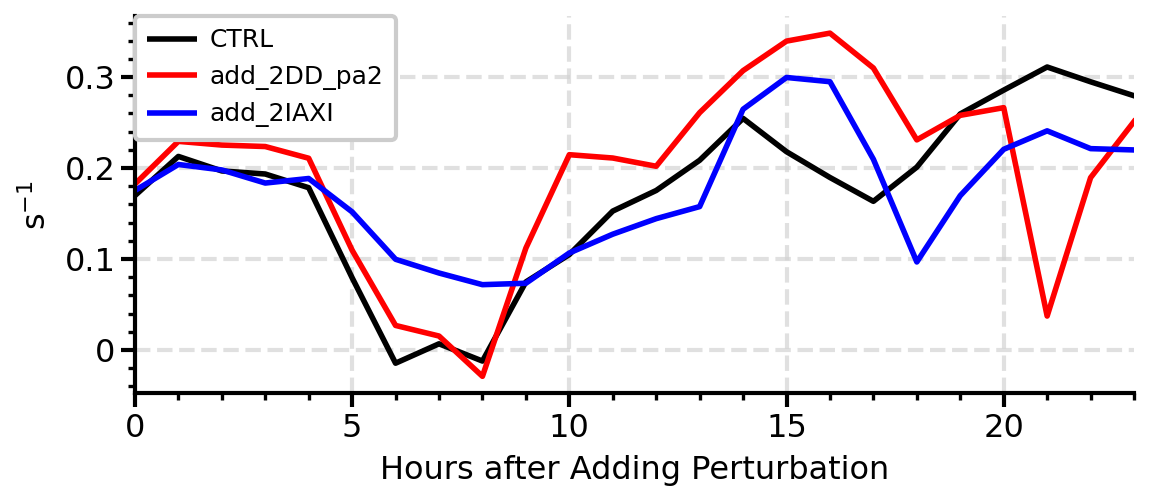

In [66]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(5.75,2.5), share=True)
am = axs[0].plot(np.mean(PVvarbudget_dict['CTRL']['LWMSE'][:,:33,:],axis=(1,2)), c='k', lw=2, label='CTRL')
am = axs[0].plot(np.mean(PVvarbudget_dict['DD_P2F']['LWMSE'][:,:33,:],axis=(1,2)), c='r', lw=2, label='add_2DD_pa2')
am = axs[0].plot(np.mean(PVvarbudget_dict['AIAXI2X']['LWMSE'][:,:33,:],axis=(1,2)), c='b', lw=2, label='add_2IAXI')
axs[0].legend(ncols=1,loc=1)
axs.format(#ylim=(1000,100),
           xlabel='Hours after Adding Perturbation', ylabel='s$^{-1}$')
plt.savefig('./pics/lwmse_wrfmemb03.png',dpi=400)
plt.show()

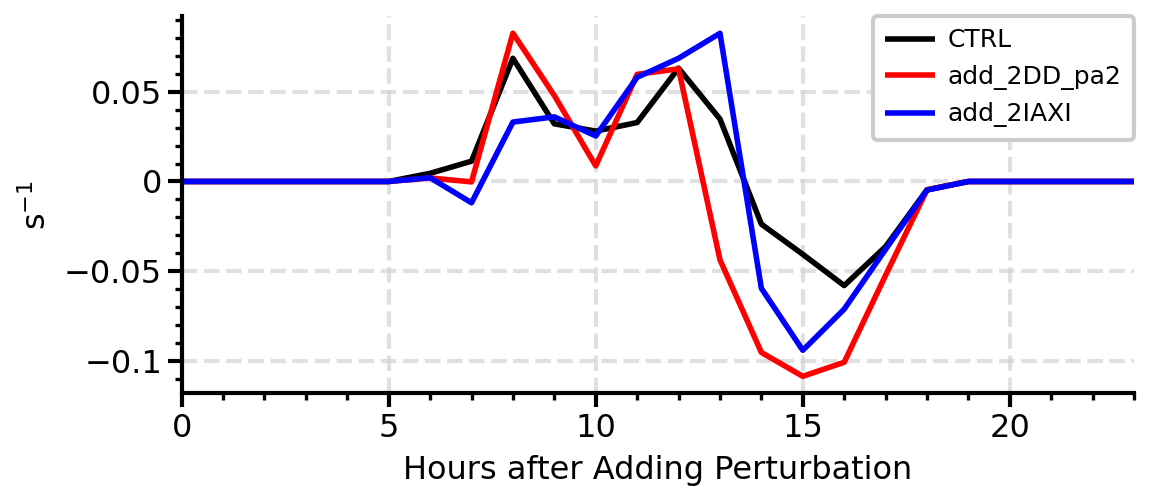

In [67]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(5.75,2.5), share=True)
am = axs[0].plot(np.nanmean(PVvarbudget_dict['CTRL']['SWMSE'][:,:33,:],axis=(1,2)), c='k', lw=2, label='CTRL')
am = axs[0].plot(np.nanmean(PVvarbudget_dict['DD_P2F']['SWMSE'][:,:33,:],axis=(1,2)), c='r', lw=2, label='add_2DD_pa2')
am = axs[0].plot(np.nanmean(PVvarbudget_dict['AIAXI2X']['SWMSE'][:,:33,:],axis=(1,2)), c='b', lw=2, label='add_2IAXI')
axs[0].legend(ncols=1,loc=1)
axs.format(#ylim=(1000,100),
           xlabel='Hours after Adding Perturbation', ylabel='s$^{-1}$')
plt.savefig('./pics/swmse_wrfmemb03.png',dpi=400)
plt.show()

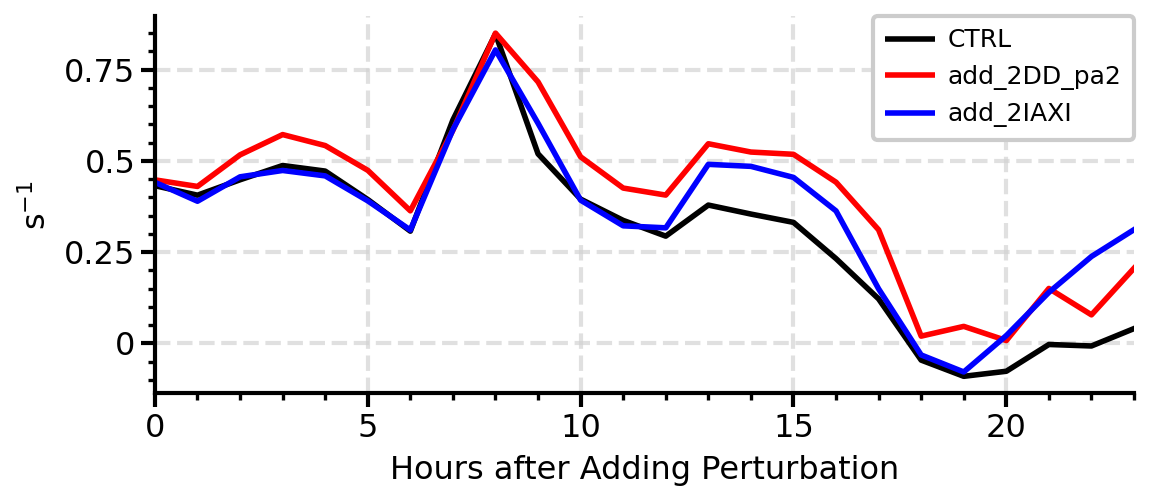

In [68]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(5.75,2.5), share=True)
am = axs[0].plot(np.nanmean(PVvarbudget_dict['CTRL']['LHmse'][:,:33,:]+PVvarbudget_dict['CTRL']['HFXmse'][:,:33,:],axis=(1,2)), 
                 c='k', lw=2, label='CTRL')
am = axs[0].plot(np.nanmean(PVvarbudget_dict['DD_P2F']['LHmse'][:,:33,:]+PVvarbudget_dict['DD_P2F']['HFXmse'][:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='add_2DD_pa2')
am = axs[0].plot(np.nanmean(PVvarbudget_dict['AIAXI2X']['LHmse'][:,:33,:]+PVvarbudget_dict['AIAXI2X']['HFXmse'][:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='add_2IAXI')
axs[0].legend(ncols=1,loc=1)
axs.format(#ylim=(1000,100),
           xlabel='Hours after Adding Perturbation', ylabel='s$^{-1}$')
plt.savefig('./pics/sfc_wrfmemb03.png',dpi=400)
plt.show()